# Group-Level SDT Multi-Route Consistency Analysis

## Motivation

Each participant answers **2 of 4** baseline questions (tp, tn, fp, fn) per theme, randomly assigned.  
Each question type independently estimates one of two population rates:

| Question | Population | Rate estimated | Formula |
|----------|-----------|----------------|----------|
| **fp** | Signal-absent | FPR | fp / 1000 |
| **tn** | Signal-absent | FPR | (1000 − tn) / 1000 |
| **tp** | Signal-present | TPR | tp / 1000 |
| **fn** | Signal-present | TPR | (1000 − fn) / 1000 |

At the **group level**, we can pool responses from people who got different questions to produce  
the same SDT parameter via different routes. If people are consistent, the routes should agree.  
If they diverge, it reveals **framing effects**: asking about errors vs. correct outcomes  
systematically shifts perceived rates.

### The 6 possible pairs and what they yield

| Pair | Category | FPR source | TPR source | SDT? | Consistency? |
|------|----------|-----------|-----------|------|-------------|
| fp+tp | SDT (direct errors) | fp→direct | tp→direct | ✓ | |
| fp+fn | SDT (both errors) | fp→direct | fn→complement | ✓ | |
| tn+tp | SDT (both correct) | tn→complement | tp→direct | ✓ | |
| tn+fn | SDT (complement) | tn→complement | fn→complement | ✓ | |
| fp+tn | Consistency | — | — | | ✓ (sum→1000) |
| fn+tp | Consistency | — | — | | ✓ (sum→1000) |

The 4 SDT-computable pairs give us **4 routes to group c and d'**.  
We compare these routes **by party** and **by theme**.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.facecolor': 'white'
})

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

THEMES = ['disease', 'armed', 'conv', 'welfare', 'immi', 'vote', 'air', 'firearm', 'auto']

THEME_LABELS = {
    'disease': 'Disease Screening',
    'armed': 'Armed Conflict',
    'conv': 'Criminal Justice',
    'welfare': 'Welfare Benefits',
    'immi': 'Immigration',
    'vote': 'Voting Rights',
    'air': 'Airport Security',
    'firearm': 'Firearm Checks',
    'auto': 'Autonomous Driving'
}

THEME_SHORT = {
    'disease': 'Disease', 'armed': 'Armed', 'conv': 'Crime',
    'welfare': 'Welfare', 'immi': 'Immig.', 'vote': 'Voting',
    'air': 'Airport', 'firearm': 'Firearms', 'auto': 'Auto'
}

# Column patterns
def base_col(theme, qtype):
    return f'base_{theme}_{qtype}'

# Party
PARTY_COL = 'party_id_7'
PARTY_GROUPS = {
    'Democrat': [1, 2, 3],
    'Republican': [5, 6, 7]
}
PARTY_COLORS = {'Democrat': '#2166ac', 'Republican': '#b2182b'}

# Haldane-Anscombe clipping
CLIP_LO, CLIP_HI = 0.001, 0.999

In [3]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# =============================================================================
# LOAD YOUR DATA  —  adjust path as needed
# =============================================================================
df = pd.read_csv('/content/drive/My Drive/Projects/SDT/Data/cleaned_data.csv')

print(f'Loaded: {len(df)} rows')
print(f'Party distribution:')
print(df[PARTY_COL].value_counts().sort_index())

Loaded: 594 rows
Party distribution:
party_id_7
1    150
2     90
3     66
4     74
5     41
6     76
7     97
Name: count, dtype: int64


# Data Transformation
Run after loading the CSV. Standardizes Qualtrics column names to the `base_{theme}_{type}` format expected by the analysis.

In [5]:
"""
=============================================================================
DATA TRANSFORMATION BLOCK
=============================================================================
Handles column standardization so that raw Qualtrics exports work with the
multi-route SDT analysis below.

This notebook primarily needs:
  - base_{theme}_{tp/fp/tn/fn}: Raw base-rate belief counts (out of 1000)
  - party_id_7: 7-point party identification

Column standardization covers:
  - {raw_theme}_{TYPE}_1 -> base_{std_theme}_{type}
    (crime->conv, walfare->welfare, immigrant->immi)
  - Qualtrics metadata row removal
  - Numeric type coercion for base-rate and party columns
=============================================================================
"""

import pandas as pd
import numpy as np
import re

THEME_RAW_TO_STD = {
    'disease': 'disease', 'armed': 'armed',
    'crime': 'conv', 'conv': 'conv',
    'walfare': 'welfare', 'welfare': 'welfare',
    'immigrant': 'immi', 'immi': 'immi',
    'vote': 'vote', 'air': 'air',
    'firearm': 'firearm', 'auto': 'auto',
}
THEMES = ['disease', 'armed', 'conv', 'welfare', 'immi', 'vote', 'air', 'firearm', 'auto']
SDT_TYPES = ['tp', 'fp', 'tn', 'fn']

# ----- Drop Qualtrics metadata rows -----
if len(df) > 2:
    first_row = df.iloc[0].astype(str)
    if first_row.str.len().mean() > 50 or first_row.str.contains('ImportId', na=False).any():
        rows_to_drop = [0]
        second_row = df.iloc[1].astype(str)
        if second_row.str.contains('ImportId', na=False).any():
            rows_to_drop.append(1)
        df = df.drop(index=rows_to_drop).reset_index(drop=True)
        print(f"  Dropped {len(rows_to_drop)} metadata row(s)")

# ----- Column standardization -----
rename = {}

# Base-rate data: {raw_theme}_{TYPE}_1 -> base_{std_theme}_{type}
pat = re.compile(r'^([a-zA-Z]+)_(TP|FP|TN|FN)_1$')
for col in df.columns:
    m = pat.match(col)
    if m:
        raw = m.group(1).lower()
        std = THEME_RAW_TO_STD.get(raw)
        if std:
            new = f'base_{std}_{m.group(2).lower()}'
            if col != new:
                rename[col] = new

if rename:
    df = df.rename(columns=rename)
    print(f"  Renamed {len(rename)} columns")

# ----- Numeric coercion -----
if 'party_id_7' in df.columns:
    df['party_id_7'] = pd.to_numeric(df['party_id_7'], errors='coerce')

for theme in THEMES:
    for qt in SDT_TYPES:
        col = f'base_{theme}_{qt}'
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# ----- Derive party_id_7 from raw Qualtrics columns if missing -----
if 'party_id_7' not in df.columns and 'pid.4' in df.columns:
    def build_party_id_7(row):
        pid = row.get('pid.4', '')
        if pd.isna(pid): return np.nan
        pid = str(pid).strip()
        if pid == 'Democrat':
            s = row.get('strong.dem', '')
            return 1 if str(s).strip() == 'Strong' else 2
        elif pid == 'Republican':
            s = row.get('strong.rep', '')
            return 7 if str(s).strip() == 'Strong' else 6
        elif pid in ('Independent', 'Other'):
            lean = str(row.get('lean', '')).strip()
            if 'Democrat' in lean: return 3
            elif 'Republican' in lean: return 5
            return 4
        return np.nan
    df['party_id_7'] = df.apply(build_party_id_7, axis=1)

# ----- Summary -----
base_cols = [f'base_{t}_{qt}' for t in THEMES for qt in SDT_TYPES if f'base_{t}_{qt}' in df.columns]
n_with_data = (df[base_cols].notna().any(axis=1)).sum() if base_cols else 0
print(f"\n  Data Transformation Complete")
print(f"  Rows: {len(df)}, Base-rate columns: {len(base_cols)}, Participants with base-rate data: {n_with_data}")



  Data Transformation Complete
  Rows: 594, Base-rate columns: 36, Participants with base-rate data: 594


---
## 1. Core Functions: Group-Level SDT via Multiple Routes

In [6]:
def safe_col(df, col):
    """Get numeric values from a column, dropping NaN."""
    if col not in df.columns:
        return pd.Series(dtype=float)
    return pd.to_numeric(df[col], errors='coerce').dropna()


def sdt_from_rates(fpr, tpr):
    """Compute d' and c from group-level FPR and TPR."""
    fpr_c = np.clip(fpr, CLIP_LO, CLIP_HI)
    tpr_c = np.clip(tpr, CLIP_LO, CLIP_HI)
    z_fa = stats.norm.ppf(fpr_c)
    z_hit = stats.norm.ppf(tpr_c)
    d_prime = z_hit - z_fa
    c = -0.5 * (z_hit + z_fa)
    return d_prime, c, z_hit, z_fa


def group_rates_by_source(df, theme):
    """
    Get group-level FPR and TPR from each of the 4 raw question columns.

    Returns dict with keys 'fp', 'tn', 'tp', 'fn', each containing:
        rate, n, se, source_population, direction
    """
    sources = {}

    # FPR sources (signal-absent population)
    fp_vals = safe_col(df, base_col(theme, 'fp'))
    if len(fp_vals) > 0:
        rates = fp_vals / 1000
        sources['fp'] = {
            'rate': rates.mean(), 'n': len(rates), 'se': rates.std() / np.sqrt(len(rates)),
            'estimates': 'FPR', 'via': 'direct', 'raw_mean': fp_vals.mean()
        }

    tn_vals = safe_col(df, base_col(theme, 'tn'))
    if len(tn_vals) > 0:
        rates = (1000 - tn_vals) / 1000
        sources['tn'] = {
            'rate': rates.mean(), 'n': len(rates), 'se': rates.std() / np.sqrt(len(rates)),
            'estimates': 'FPR', 'via': 'complement', 'raw_mean': tn_vals.mean()
        }

    # TPR sources (signal-present population)
    tp_vals = safe_col(df, base_col(theme, 'tp'))
    if len(tp_vals) > 0:
        rates = tp_vals / 1000
        sources['tp'] = {
            'rate': rates.mean(), 'n': len(rates), 'se': rates.std() / np.sqrt(len(rates)),
            'estimates': 'TPR', 'via': 'direct', 'raw_mean': tp_vals.mean()
        }

    fn_vals = safe_col(df, base_col(theme, 'fn'))
    if len(fn_vals) > 0:
        rates = (1000 - fn_vals) / 1000
        sources['fn'] = {
            'rate': rates.mean(), 'n': len(rates), 'se': rates.std() / np.sqrt(len(rates)),
            'estimates': 'TPR', 'via': 'complement', 'raw_mean': fn_vals.mean()
        }

    return sources


def all_sdt_routes(df, theme):
    """
    Compute group d' and c via ALL possible routes for a theme.

    4 SDT-computable routes (pairs that span both populations):
      Route fp+tp: FPR from fp (direct),     TPR from tp (direct)
      Route fp+fn: FPR from fp (direct),     TPR from fn (complement)
      Route tn+tp: FPR from tn (complement), TPR from tp (direct)
      Route tn+fn: FPR from tn (complement), TPR from fn (complement)

    Returns list of dicts, one per computable route.
    """
    src = group_rates_by_source(df, theme)

    # Define the 4 SDT routes: (FPR_source, TPR_source)
    route_defs = {
        'fp+tp': ('fp', 'tp'),   # both direct
        'fp+fn': ('fp', 'fn'),   # direct FPR, complement TPR
        'tn+tp': ('tn', 'tp'),   # complement FPR, direct TPR
        'tn+fn': ('tn', 'fn'),   # both complement
    }

    results = []
    for route_name, (fpr_key, tpr_key) in route_defs.items():
        if fpr_key not in src or tpr_key not in src:
            continue

        fpr = src[fpr_key]['rate']
        tpr = src[tpr_key]['rate']
        d_prime, c, z_hit, z_fa = sdt_from_rates(fpr, tpr)

        results.append({
            'route': route_name,
            'fpr_source': fpr_key, 'tpr_source': tpr_key,
            'fpr_via': src[fpr_key]['via'], 'tpr_via': src[tpr_key]['via'],
            'fpr': fpr, 'tpr': tpr,
            'n_fpr': src[fpr_key]['n'], 'n_tpr': src[tpr_key]['n'],
            'fpr_se': src[fpr_key]['se'], 'tpr_se': src[tpr_key]['se'],
            'd_prime': d_prime, 'c': c,
            'z_hit': z_hit, 'z_fa': z_fa,
        })

    return results

---
## 2. Compute All Routes × All Themes × Both Parties

In [7]:
rows = []
for party_label, pid_vals in PARTY_GROUPS.items():
    sub = df[df[PARTY_COL].isin(pid_vals)]
    for theme in THEMES:
        routes = all_sdt_routes(sub, theme)
        for r in routes:
            r['party'] = party_label
            r['theme'] = theme
            r['theme_label'] = THEME_LABELS[theme]
            rows.append(r)

# Also compute overall (all participants)
for theme in THEMES:
    routes = all_sdt_routes(df, theme)
    for r in routes:
        r['party'] = 'Overall'
        r['theme'] = theme
        r['theme_label'] = THEME_LABELS[theme]
        rows.append(r)

rt = pd.DataFrame(rows)
print(f'Computed {len(rt)} route estimates across parties and themes')
print(f'Routes available per theme-party combination:')
print(rt.groupby(['party', 'theme'])['route'].count().unstack(fill_value=0))

Computed 108 route estimates across parties and themes
Routes available per theme-party combination:
theme       air  armed  auto  conv  disease  firearm  immi  vote  welfare
party                                                                    
Democrat      4      4     4     4        4        4     4     4        4
Overall       4      4     4     4        4        4     4     4        4
Republican    4      4     4     4        4        4     4     4        4


In [8]:
# Quick summary: how much do routes disagree?
print('\n' + '='*80)
print('ROUTE AGREEMENT DIAGNOSTIC: Range of c and d\' across routes')
print('='*80)

for party in ['Democrat', 'Republican', 'Overall']:
    print(f'\n  {party.upper()}')
    sub = rt[rt['party'] == party]
    for theme in THEMES:
        t = sub[sub['theme'] == theme]
        if len(t) < 2:
            continue
        c_range = t['c'].max() - t['c'].min()
        d_range = t['d_prime'].max() - t['d_prime'].min()
        print(f'    {THEME_LABELS[theme]:<22} '
              f'c: [{t["c"].min():+.3f} to {t["c"].max():+.3f}] range={c_range:.3f}   '
              f'd\': [{t["d_prime"].min():.3f} to {t["d_prime"].max():.3f}] range={d_range:.3f}')


ROUTE AGREEMENT DIAGNOSTIC: Range of c and d' across routes

  DEMOCRAT
    Disease Screening      c: [-0.155 to +0.244] range=0.399   d': [1.266 to 2.063] range=0.797
    Armed Conflict         c: [-0.117 to +0.189] range=0.306   d': [1.237 to 1.849] range=0.612
    Criminal Justice       c: [-0.170 to +0.018] range=0.188   d': [1.170 to 1.546] range=0.377
    Welfare Benefits       c: [-0.156 to +0.125] range=0.281   d': [0.986 to 1.548] range=0.562
    Immigration            c: [-0.245 to +0.007] range=0.252   d': [0.851 to 1.356] range=0.505
    Voting Rights          c: [-0.146 to +0.164] range=0.311   d': [1.538 to 2.160] range=0.622
    Airport Security       c: [-0.210 to +0.159] range=0.369   d': [0.958 to 1.696] range=0.737
    Firearm Checks         c: [+0.022 to +0.365] range=0.343   d': [1.061 to 1.747] range=0.686
    Autonomous Driving     c: [-0.058 to +0.080] range=0.138   d': [1.237 to 1.512] range=0.276

  REPUBLICAN
    Disease Screening      c: [-0.177 to +0.128] 

---
## 3. Underlying Rate Comparison: Direct vs. Complement

Before looking at SDT parameters, compare the raw rates.  
Does asking "how many FP?" give a different FPR than asking "how many TN?" → (1-TN/1000)?  
This is the **valence framing** effect (H6 from brainstorming doc).

In [9]:
rate_rows = []
for party_label in ['Democrat', 'Republican', 'Overall']:
    if party_label == 'Overall':
        sub = df
    else:
        sub = df[df[PARTY_COL].isin(PARTY_GROUPS[party_label])]

    for theme in THEMES:
        src = group_rates_by_source(sub, theme)
        for qtype, info in src.items():
            rate_rows.append({
                'party': party_label, 'theme': theme,
                'theme_label': THEME_LABELS[theme],
                'question': qtype, 'estimates': info['estimates'],
                'via': info['via'], 'rate': info['rate'],
                'n': info['n'], 'se': info['se'],
                'raw_mean': info['raw_mean']
            })

rates_df = pd.DataFrame(rate_rows)

# Compare FPR: fp (direct) vs tn (complement)
print('='*85)
print('FPR COMPARISON: Direct (from fp) vs Complement (from 1-tn/1000)')
print('='*85)
for party in ['Democrat', 'Republican']:
    print(f'\n  {party}')
    for theme in THEMES:
        fp_row = rates_df[(rates_df['party']==party) & (rates_df['theme']==theme) & (rates_df['question']=='fp')]
        tn_row = rates_df[(rates_df['party']==party) & (rates_df['theme']==theme) & (rates_df['question']=='tn')]
        if len(fp_row) > 0 and len(tn_row) > 0:
            delta = fp_row['rate'].values[0] - tn_row['rate'].values[0]
            print(f'    {THEME_SHORT[theme]:<10} FPR_fp={fp_row["rate"].values[0]:.3f} (n={fp_row["n"].values[0]:.0f})  '
                  f'FPR_tn={tn_row["rate"].values[0]:.3f} (n={tn_row["n"].values[0]:.0f})  '
                  f'Δ={delta:+.3f}')

print('\n' + '='*85)
print('TPR COMPARISON: Direct (from tp) vs Complement (from 1-fn/1000)')
print('='*85)
for party in ['Democrat', 'Republican']:
    print(f'\n  {party}')
    for theme in THEMES:
        tp_row = rates_df[(rates_df['party']==party) & (rates_df['theme']==theme) & (rates_df['question']=='tp')]
        fn_row = rates_df[(rates_df['party']==party) & (rates_df['theme']==theme) & (rates_df['question']=='fn')]
        if len(tp_row) > 0 and len(fn_row) > 0:
            delta = tp_row['rate'].values[0] - fn_row['rate'].values[0]
            print(f'    {THEME_SHORT[theme]:<10} TPR_tp={tp_row["rate"].values[0]:.3f} (n={tp_row["n"].values[0]:.0f})  '
                  f'TPR_fn={fn_row["rate"].values[0]:.3f} (n={fn_row["n"].values[0]:.0f})  '
                  f'Δ={delta:+.3f}')

FPR COMPARISON: Direct (from fp) vs Complement (from 1-tn/1000)

  Democrat
    Disease    FPR_fp=0.135 (n=161)  FPR_tn=0.258 (n=174)  Δ=-0.123
    Armed      FPR_fp=0.160 (n=171)  FPR_tn=0.267 (n=182)  Δ=-0.107
    Crime      FPR_fp=0.247 (n=164)  FPR_tn=0.301 (n=184)  Δ=-0.055
    Welfare    FPR_fp=0.270 (n=176)  FPR_tn=0.267 (n=184)  Δ=+0.002
    Immig.     FPR_fp=0.334 (n=175)  FPR_tn=0.331 (n=178)  Δ=+0.003
    Voting     FPR_fp=0.164 (n=161)  FPR_tn=0.187 (n=165)  Δ=-0.022
    Airport    FPR_fp=0.237 (n=171)  FPR_tn=0.288 (n=169)  Δ=-0.051
    Firearms   FPR_fp=0.123 (n=168)  FPR_tn=0.265 (n=177)  Δ=-0.142
    Auto       FPR_fp=0.224 (n=183)  FPR_tn=0.262 (n=160)  Δ=-0.038

  Republican
    Disease    FPR_fp=0.181 (n=96)  FPR_tn=0.312 (n=129)  Δ=-0.131
    Armed      FPR_fp=0.163 (n=126)  FPR_tn=0.303 (n=117)  Δ=-0.140
    Crime      FPR_fp=0.239 (n=124)  FPR_tn=0.311 (n=110)  Δ=-0.072
    Welfare    FPR_fp=0.253 (n=123)  FPR_tn=0.267 (n=129)  Δ=-0.014
    Immig.     FPR_fp=0.243

---
## 4. ROC Curves with Multi-Route Points, Criterion Lines, and Bayesian Optimal

For each theme, plot:
- The **ROC point** (FPR, TPR) for each party × each estimation route
- The **iso-criterion line** through the ROC point (slope = 1, perpendicular to the major diagonal)
- The **Bayesian optimal criterion** line, given a base rate prior

### The diagonal through the ROC point
The criterion c is geometrically represented as a line with **slope = 1** in z-space,  
which maps to a specific curve in ROC space. For the iso-c diagonal through  
the operating point: in ROC space where x=FPR and y=TPR, the line of constant c  
at a given d' passes through (FPR, TPR) with a tangent related to the likelihood ratio.

More intuitively: the **diagonal from (0,0) to (1,1)** represents d'=0 (chance).  
A point above this diagonal has d'>0. The criterion line through a point  
is the iso-criterion contour of the ROC curve defined by that point's d'.

### Bayesian optimal criterion
The optimal criterion balances base rate and costs:  
$$c_{opt} = -\frac{1}{2}d' + \frac{\ln(\frac{1-p}{p})}{d'}$$  
where $p$ = P(signal) = base rate of the target condition.  
(Assuming equal error costs. With unequal costs, add $\frac{\ln(C_{FP}/C_{FN})}{d'}$.)

In [10]:
def roc_curve_from_dprime(d_prime, n_points=200):
    """
    Generate the full ROC curve for a given d'.
    Sweeps criterion from very liberal to very conservative.
    """
    # Sweep criterion c
    c_vals = np.linspace(-4, 4, n_points)
    # z_fa = -c - d'/2;  z_hit = d'/2 - c  (from c = -0.5(z_hit+z_fa) and d'=z_hit-z_fa)
    # Actually: z_hit = d'/2 - c;  z_fa = -(d'/2 + c)
    z_fa = -(d_prime / 2 + c_vals)
    z_hit = d_prime / 2 - c_vals
    fpr = stats.norm.cdf(z_fa)  # = P(response | noise) = P(FA)
    tpr = stats.norm.cdf(z_hit) # = P(response | signal) = P(Hit)
    return fpr, tpr


def criterion_line_on_roc(d_prime, c_val, n_points=100):
    """
    The iso-criterion line on the ROC curve.
    For a fixed c, varying d' traces a curve. But the more useful
    visualization is the tangent to the ROC at the operating point,
    which has slope = likelihood ratio = exp(d' * c + d'^2/2) ...

    Simpler: draw a line from the ROC point perpendicular to the
    negative diagonal (in z-space, c = const is a line with slope 1).
    In probability space, this maps via the normal CDF.
    """
    # In z-space: z_hit = z_fa + d' (the ROC curve)
    # The criterion line: z_hit = -z_fa - 2c (constant c)
    # These intersect at the operating point
    z_fa_range = np.linspace(-3.5, 3.5, n_points)
    z_hit_line = -z_fa_range - 2 * c_val
    fpr_line = stats.norm.cdf(z_fa_range)
    tpr_line = stats.norm.cdf(z_hit_line)
    # Clip to valid ROC region
    mask = (fpr_line >= 0) & (fpr_line <= 1) & (tpr_line >= 0) & (tpr_line <= 1)
    return fpr_line[mask], tpr_line[mask]


def bayesian_optimal_c(d_prime, base_rate, cost_ratio=1.0):
    """
    Bayesian optimal criterion given d', base rate, and cost ratio.

    c_opt = ln((1-p)/p * C_fp/C_fn) / d'

    With equal costs (cost_ratio=1): c_opt = ln((1-p)/p) / d'

    Note: This is the *ideal observer* criterion. c_opt = 0 when p = 0.5 and costs equal.
    """
    if d_prime == 0 or base_rate <= 0 or base_rate >= 1:
        return np.nan
    log_odds = np.log((1 - base_rate) / base_rate)
    return log_odds / d_prime


def c_to_roc_point(d_prime, c_val):
    """Convert (d', c) to (FPR, TPR) on the ROC curve."""
    z_fa = -(d_prime / 2 + c_val)
    z_hit = d_prime / 2 - c_val
    return stats.norm.cdf(z_fa), stats.norm.cdf(z_hit)

In [11]:
# =============================================================================
# BASE RATE PRIORS for Bayesian optimal c
# These are rough estimates — adjust based on your domain knowledge or
# use participants' own base-rate beliefs as priors
# =============================================================================

# Option 1: Use a generic "uninformative" prior of 0.5 (c_opt = 0)
# Option 2: Use rough real-world base rates
# Option 3: Use group mean base-rate beliefs from the survey data

# We'll compute Option 3 from the data if available, falling back to 0.5

def estimate_group_base_rate(df, theme, party_label=None):
    """
    Estimate base rate from participants' beliefs.

    Base rate P(signal) can be inferred from the error rates:
    If participants believe FPR and TPR, then their implied base rate
    given their SDT operating point isn't directly recoverable without
    knowing the prior.

    But we can use a simpler heuristic: the overall proportion of
    'signal' in their mental model. For now, use 0.5 (neutral) or
    supply your own.
    """
    # Default: use 0.5 (unbiased Bayesian prior)
    # Override this dict with real priors if you have them
    return 0.5

# If you have actual base rate data, override here:
# e.g., from the survey's base-rate belief questions
BASE_RATE_PRIORS = {theme: 0.5 for theme in THEMES}
# Example overrides:
# BASE_RATE_PRIORS['disease'] = 0.05   # 5% prevalence
# BASE_RATE_PRIORS['immi'] = 0.10      # 10% inadmissible

print('Base rate priors for Bayesian optimal c:')
for t, p in BASE_RATE_PRIORS.items():
    print(f'  {THEME_LABELS[t]:<22} P(signal) = {p:.2f}')

Base rate priors for Bayesian optimal c:
  Disease Screening      P(signal) = 0.50
  Armed Conflict         P(signal) = 0.50
  Criminal Justice       P(signal) = 0.50
  Welfare Benefits       P(signal) = 0.50
  Immigration            P(signal) = 0.50
  Voting Rights          P(signal) = 0.50
  Airport Security       P(signal) = 0.50
  Firearm Checks         P(signal) = 0.50
  Autonomous Driving     P(signal) = 0.50


---
## 5. Main Plot: ROC Curves by Theme — Two Parties, Multi-Route, with c Lines

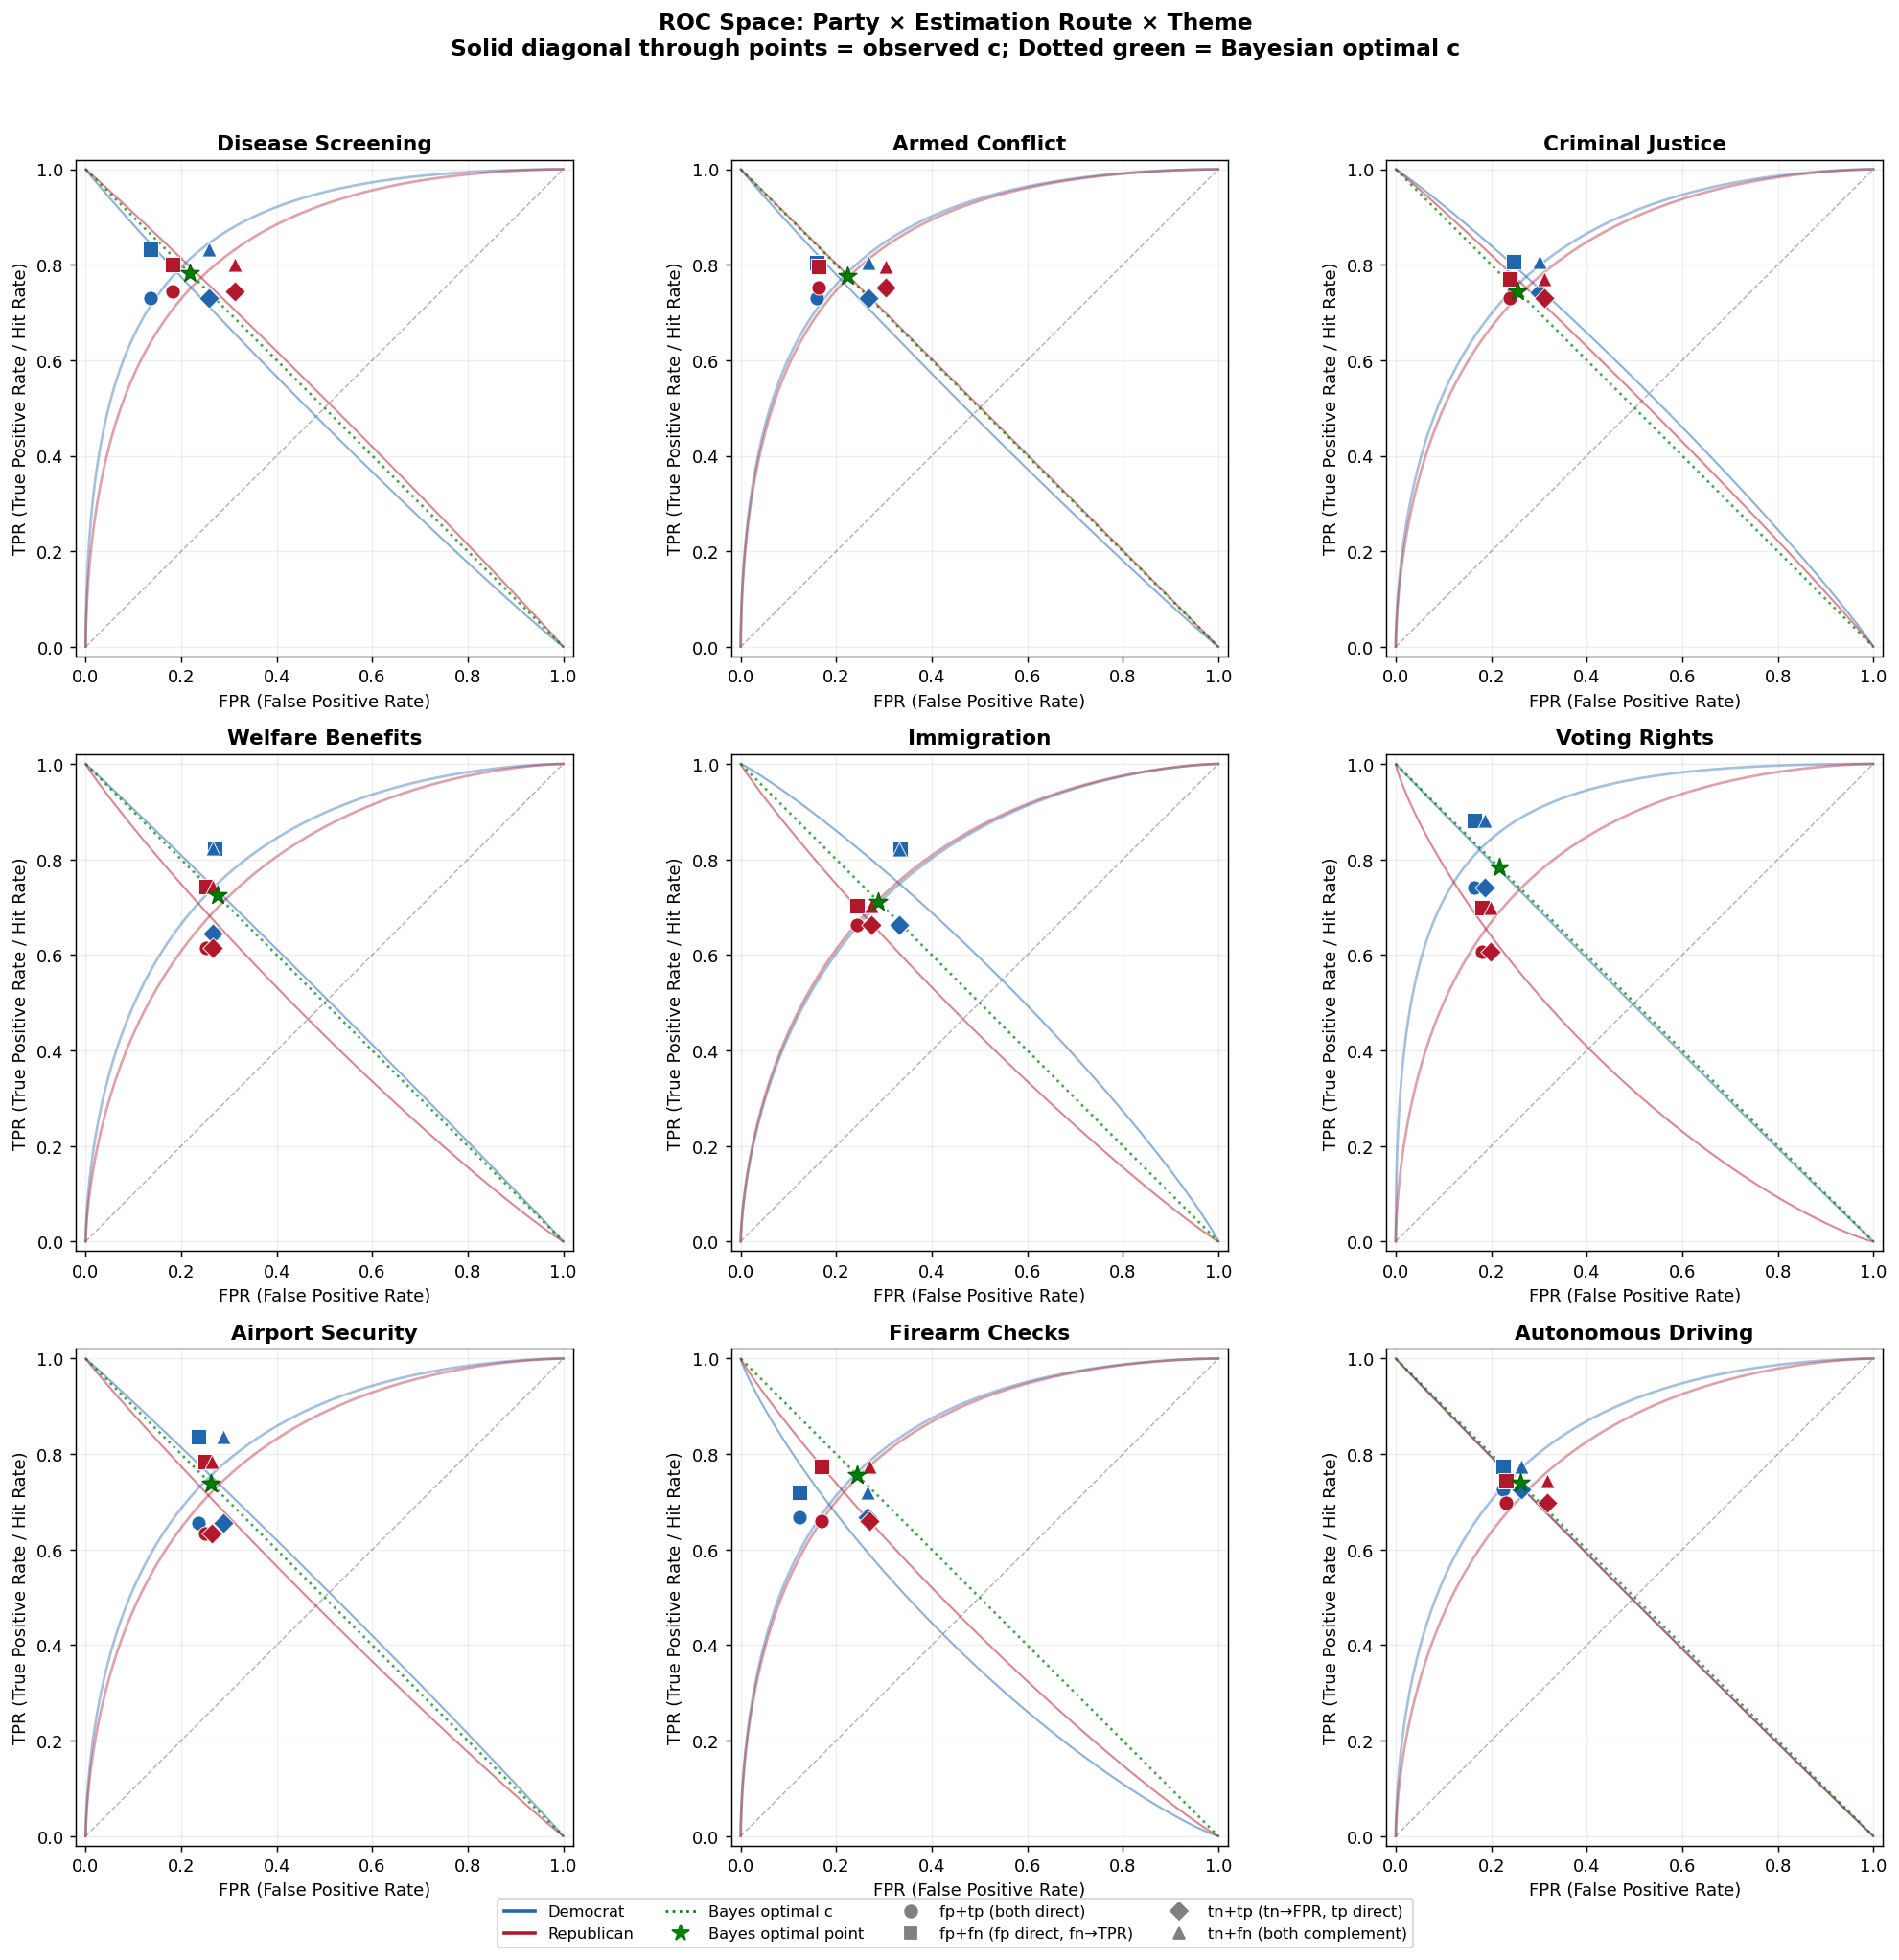

In [12]:
ROUTE_MARKERS = {
    'fp+tp': 'o',    # both direct
    'fp+fn': 's',    # direct FPR, complement TPR
    'tn+tp': 'D',    # complement FPR, direct TPR
    'tn+fn': '^',    # both complement
}
ROUTE_LABELS = {
    'fp+tp': 'fp+tp (both direct)',
    'fp+fn': 'fp+fn (fp direct, fn→TPR)',
    'tn+tp': 'tn+tp (tn→FPR, tp direct)',
    'tn+fn': 'tn+fn (both complement)',
}

fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes = axes.flatten()

for idx, theme in enumerate(THEMES):
    ax = axes[idx]

    # Chance line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)

    # Collect d' values to draw the ROC envelope
    d_primes_all = []

    for party in ['Democrat', 'Republican']:
        color = PARTY_COLORS[party]
        party_routes = rt[(rt['party'] == party) & (rt['theme'] == theme)]

        if len(party_routes) == 0:
            continue

        # Use mean d' across routes for the ROC curve
        mean_d = party_routes['d_prime'].mean()
        mean_c = party_routes['c'].mean()
        d_primes_all.append(mean_d)

        # Draw the ROC curve for mean d'
        roc_fpr, roc_tpr = roc_curve_from_dprime(mean_d)
        ax.plot(roc_fpr, roc_tpr, color=color, alpha=0.4, linewidth=1.5)

        # Plot each route as a distinct marker
        for _, row in party_routes.iterrows():
            marker = ROUTE_MARKERS.get(row['route'], 'x')
            ax.scatter(row['fpr'], row['tpr'], marker=marker, color=color,
                      s=70, zorder=5, edgecolors='white', linewidth=0.5)

        # Draw criterion line through the MEAN operating point
        c_fpr, c_tpr = criterion_line_on_roc(mean_d, mean_c)
        ax.plot(c_fpr, c_tpr, color=color, linestyle='-', alpha=0.5, linewidth=1.2)

    # Bayesian optimal criterion
    if len(d_primes_all) > 0:
        grand_d = np.mean(d_primes_all)
        base_rate = BASE_RATE_PRIORS[theme]
        c_opt = bayesian_optimal_c(grand_d, base_rate)

        if not np.isnan(c_opt):
            opt_fpr_pt, opt_tpr_pt = c_to_roc_point(grand_d, c_opt)
            # Draw the optimal criterion line
            opt_c_fpr, opt_c_tpr = criterion_line_on_roc(grand_d, c_opt)
            ax.plot(opt_c_fpr, opt_c_tpr, color='green', linestyle=':',
                    alpha=0.7, linewidth=1.5, label=f'Bayes opt (p={base_rate})')
            ax.scatter([opt_fpr_pt], [opt_tpr_pt], marker='*', color='green',
                      s=120, zorder=6, edgecolors='darkgreen', linewidth=0.8)

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.set_title(THEME_LABELS[theme], fontweight='bold')
    ax.set_xlabel('FPR (False Positive Rate)')
    ax.set_ylabel('TPR (True Positive Rate / Hit Rate)')
    ax.grid(True, alpha=0.2)

# Build legend
legend_elements = [
    Line2D([0], [0], color=PARTY_COLORS['Democrat'], lw=2, label='Democrat'),
    Line2D([0], [0], color=PARTY_COLORS['Republican'], lw=2, label='Republican'),
    Line2D([0], [0], color='green', lw=1.5, linestyle=':', label='Bayes optimal c'),
    Line2D([0], [0], marker='*', color='green', lw=0, markersize=10, label='Bayes optimal point'),
]
for route, marker in ROUTE_MARKERS.items():
    legend_elements.append(
        Line2D([0], [0], marker=marker, color='gray', lw=0, markersize=7,
               label=ROUTE_LABELS[route])
    )

fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('ROC Space: Party × Estimation Route × Theme\n'
             'Solid diagonal through points = observed c; Dotted green = Bayesian optimal c',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_multiRoute_party_theme.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Aggregated c and d' Comparison: Two Parties × Route

Bar plot showing c and d' for each party, broken down by estimation route,  
with error bars from bootstrapping.

In [13]:
def bootstrap_group_sdt(df, theme, fpr_key, tpr_key, n_boot=2000, seed=42):
    """
    Bootstrap CI for group-level d' and c via a specific route.

    fpr_key, tpr_key: 'fp','tn','tp','fn' - which raw column provides each rate
    """
    rng = np.random.default_rng(seed)

    # Get FPR values
    if fpr_key == 'fp':
        fpr_vals = safe_col(df, base_col(theme, 'fp')).values / 1000
    else:  # tn
        fpr_vals = (1000 - safe_col(df, base_col(theme, 'tn')).values) / 1000

    # Get TPR values
    if tpr_key == 'tp':
        tpr_vals = safe_col(df, base_col(theme, 'tp')).values / 1000
    else:  # fn
        tpr_vals = (1000 - safe_col(df, base_col(theme, 'fn')).values) / 1000

    if len(fpr_vals) < 3 or len(tpr_vals) < 3:
        return {'d_lo': np.nan, 'd_hi': np.nan, 'c_lo': np.nan, 'c_hi': np.nan}

    boot_d, boot_c = [], []
    for _ in range(n_boot):
        fpr_b = np.clip(rng.choice(fpr_vals, len(fpr_vals), replace=True).mean(), CLIP_LO, CLIP_HI)
        tpr_b = np.clip(rng.choice(tpr_vals, len(tpr_vals), replace=True).mean(), CLIP_LO, CLIP_HI)
        z_fa = stats.norm.ppf(fpr_b)
        z_hit = stats.norm.ppf(tpr_b)
        boot_d.append(z_hit - z_fa)
        boot_c.append(-0.5 * (z_hit + z_fa))

    return {
        'd_lo': np.percentile(boot_d, 2.5), 'd_hi': np.percentile(boot_d, 97.5),
        'c_lo': np.percentile(boot_c, 2.5), 'c_hi': np.percentile(boot_c, 97.5)
    }

In [14]:
# Compute bootstrap CIs for all party-theme-route combos
route_fpr_keys = {'fp+tp': 'fp', 'fp+fn': 'fp', 'tn+tp': 'tn', 'tn+fn': 'tn'}
route_tpr_keys = {'fp+tp': 'tp', 'fp+fn': 'fn', 'tn+tp': 'tp', 'tn+fn': 'fn'}

ci_rows = []
for _, row in rt[rt['party'].isin(['Democrat', 'Republican'])].iterrows():
    sub = df[df[PARTY_COL].isin(PARTY_GROUPS[row['party']])]
    ci = bootstrap_group_sdt(sub, row['theme'],
                             route_fpr_keys[row['route']],
                             route_tpr_keys[row['route']])
    ci_rows.append({**row.to_dict(), **ci})

rt_ci = pd.DataFrame(ci_rows)
print(f'Bootstrapped CIs for {len(rt_ci)} estimates')

Bootstrapped CIs for 72 estimates


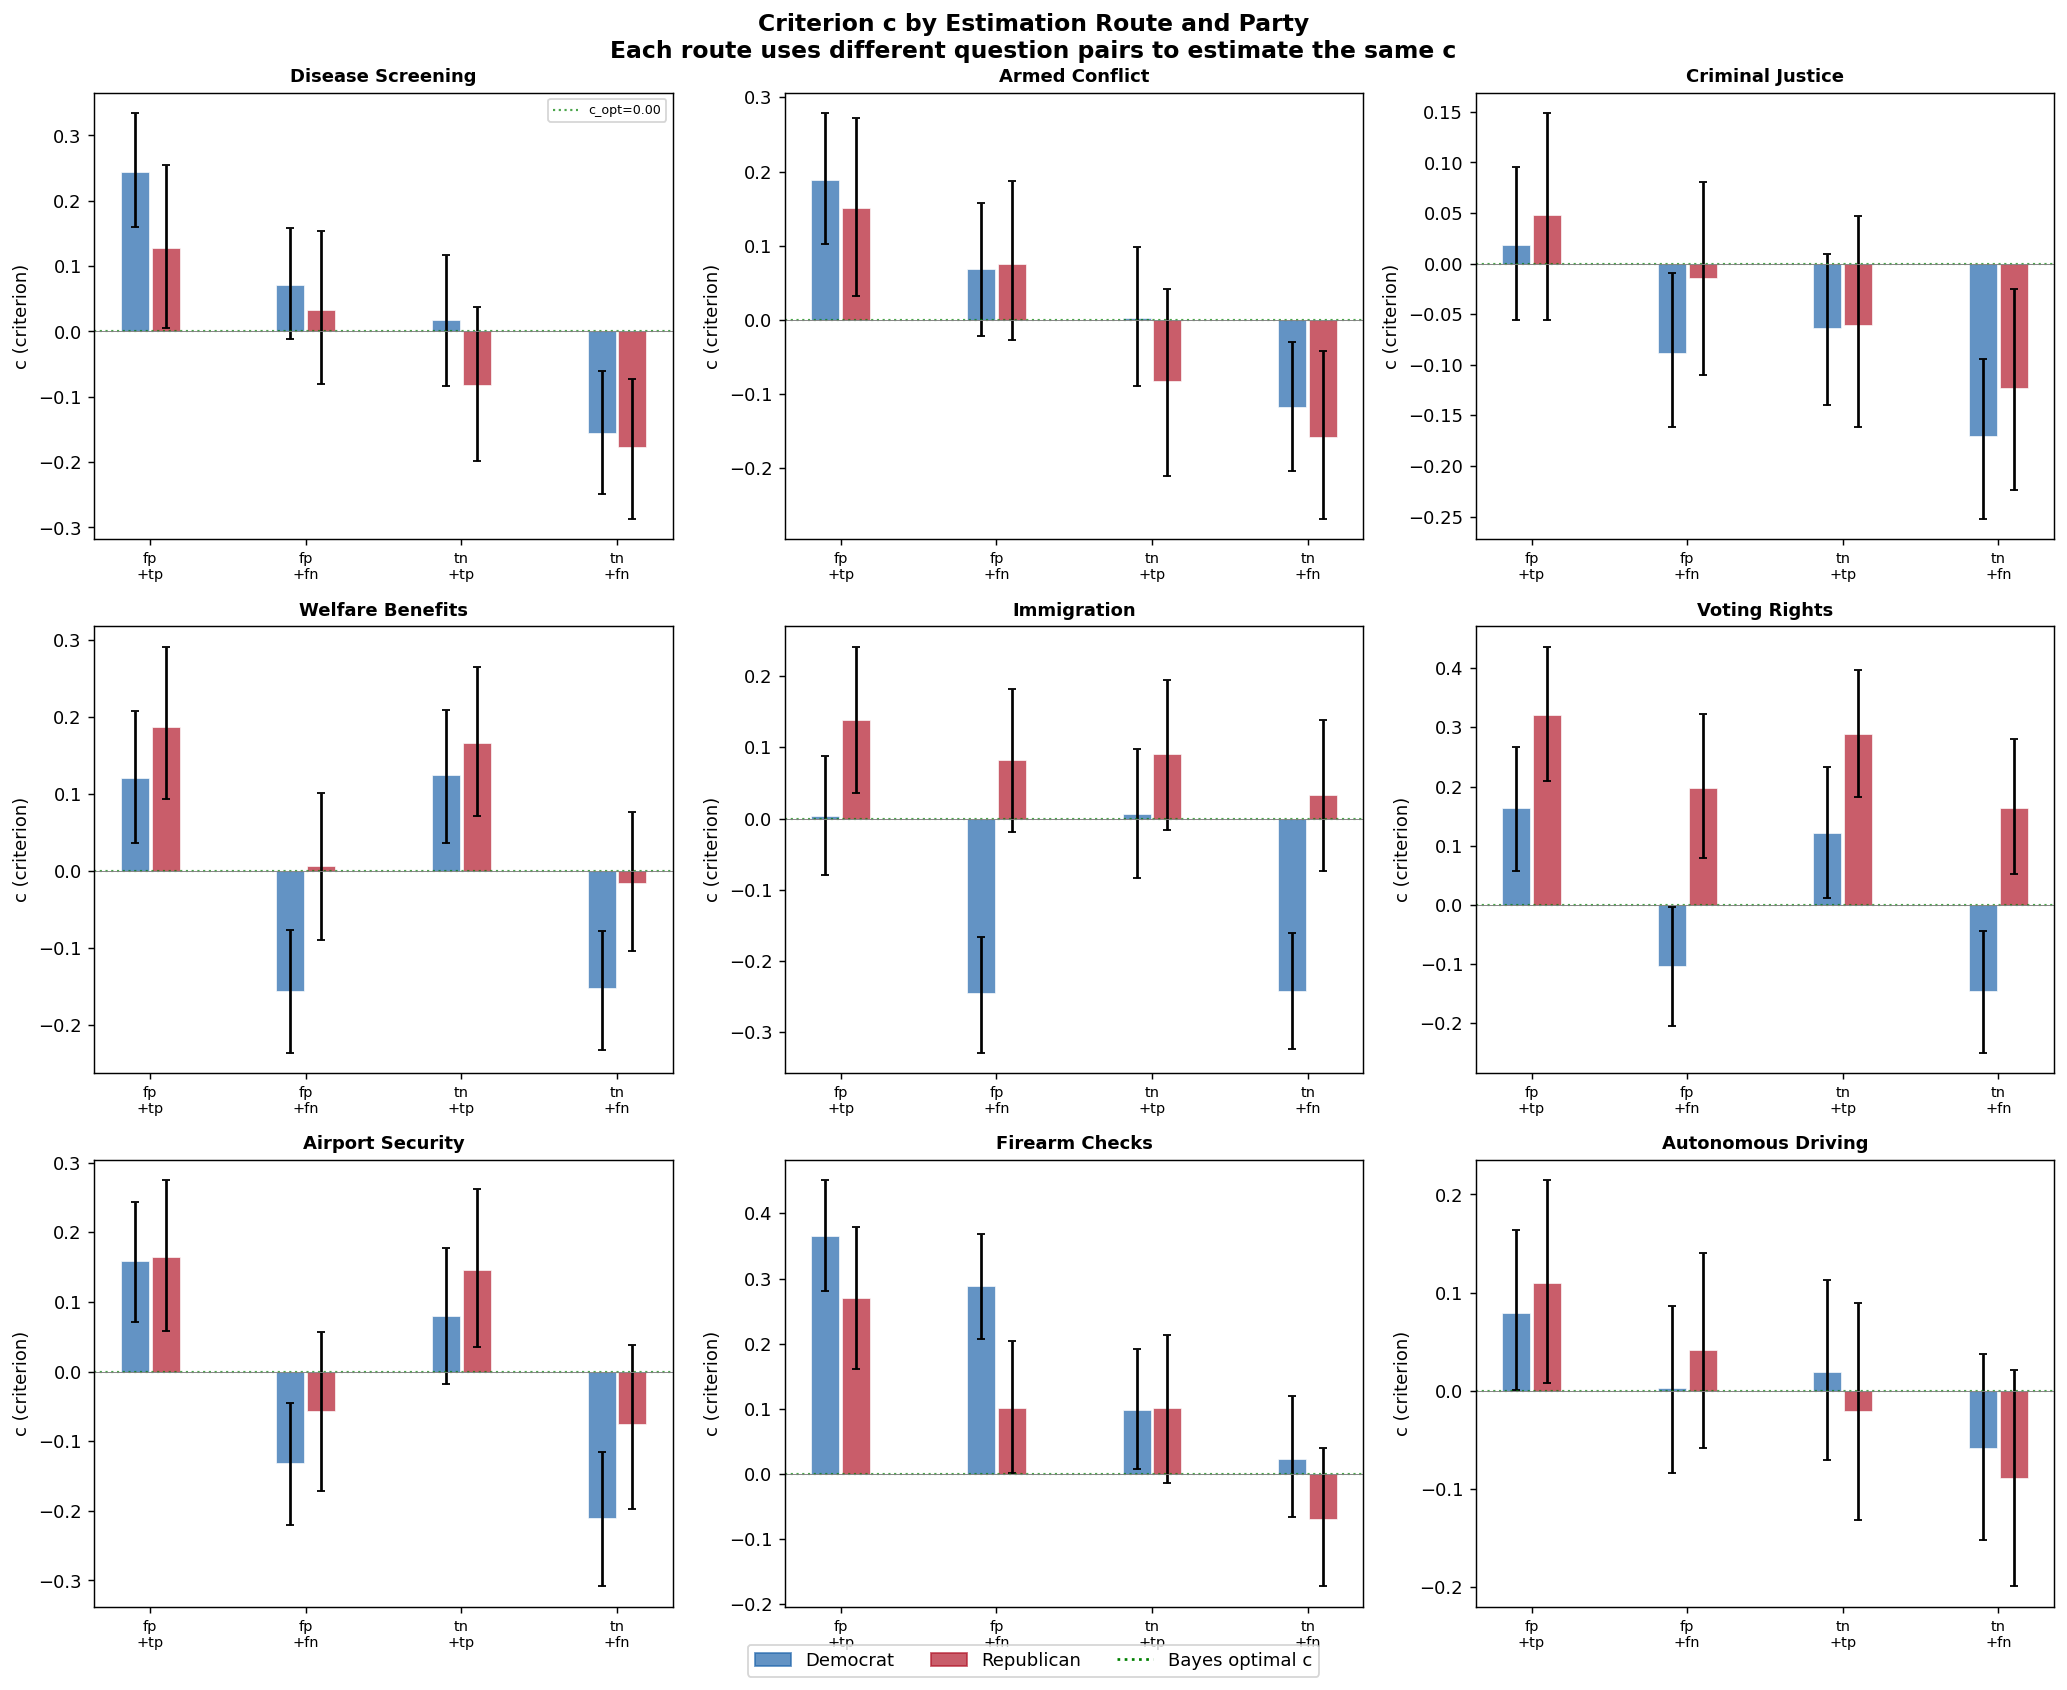

In [15]:
# --- Plot: c by party and route, across themes ---

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

routes_ordered = ['fp+tp', 'fp+fn', 'tn+tp', 'tn+fn']
bar_width = 0.18

for idx, theme in enumerate(THEMES):
    ax = axes[idx]
    t_data = rt_ci[rt_ci['theme'] == theme]

    for r_idx, route in enumerate(routes_ordered):
        for p_idx, party in enumerate(['Democrat', 'Republican']):
            row = t_data[(t_data['route'] == route) & (t_data['party'] == party)]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            x = r_idx + (p_idx - 0.5) * bar_width * 1.1

            yerr_lo = row['c'] - row['c_lo']
            yerr_hi = row['c_hi'] - row['c']
            ax.bar(x, row['c'], bar_width, color=PARTY_COLORS[party], alpha=0.7,
                   yerr=[[yerr_lo], [yerr_hi]], capsize=2, edgecolor='white', linewidth=0.5)

    # Bayesian optimal
    overall_d = rt[(rt['party']=='Overall') & (rt['theme']==theme)]['d_prime'].mean()
    if not np.isnan(overall_d) and overall_d != 0:
        c_opt = bayesian_optimal_c(overall_d, BASE_RATE_PRIORS[theme])
        if not np.isnan(c_opt):
            ax.axhline(c_opt, color='green', linestyle=':', linewidth=1.2, alpha=0.7,
                       label=f'c_opt={c_opt:.2f}')

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xticks(range(len(routes_ordered)))
    ax.set_xticklabels([r.replace('+', '\n+') for r in routes_ordered], fontsize=8)
    ax.set_title(THEME_LABELS[theme], fontweight='bold', fontsize=10)
    ax.set_ylabel('c (criterion)')
    if idx == 0:
        ax.legend(fontsize=7, loc='best')

# Legend
dem_patch = mpatches.Patch(color=PARTY_COLORS['Democrat'], alpha=0.7, label='Democrat')
rep_patch = mpatches.Patch(color=PARTY_COLORS['Republican'], alpha=0.7, label='Republican')
opt_line = Line2D([0], [0], color='green', linestyle=':', label='Bayes optimal c')
fig.legend(handles=[dem_patch, rep_patch, opt_line], loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Criterion c by Estimation Route and Party\n'
             'Each route uses different question pairs to estimate the same c',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('c_by_route_party_theme.png', dpi=150, bbox_inches='tight')
plt.show()

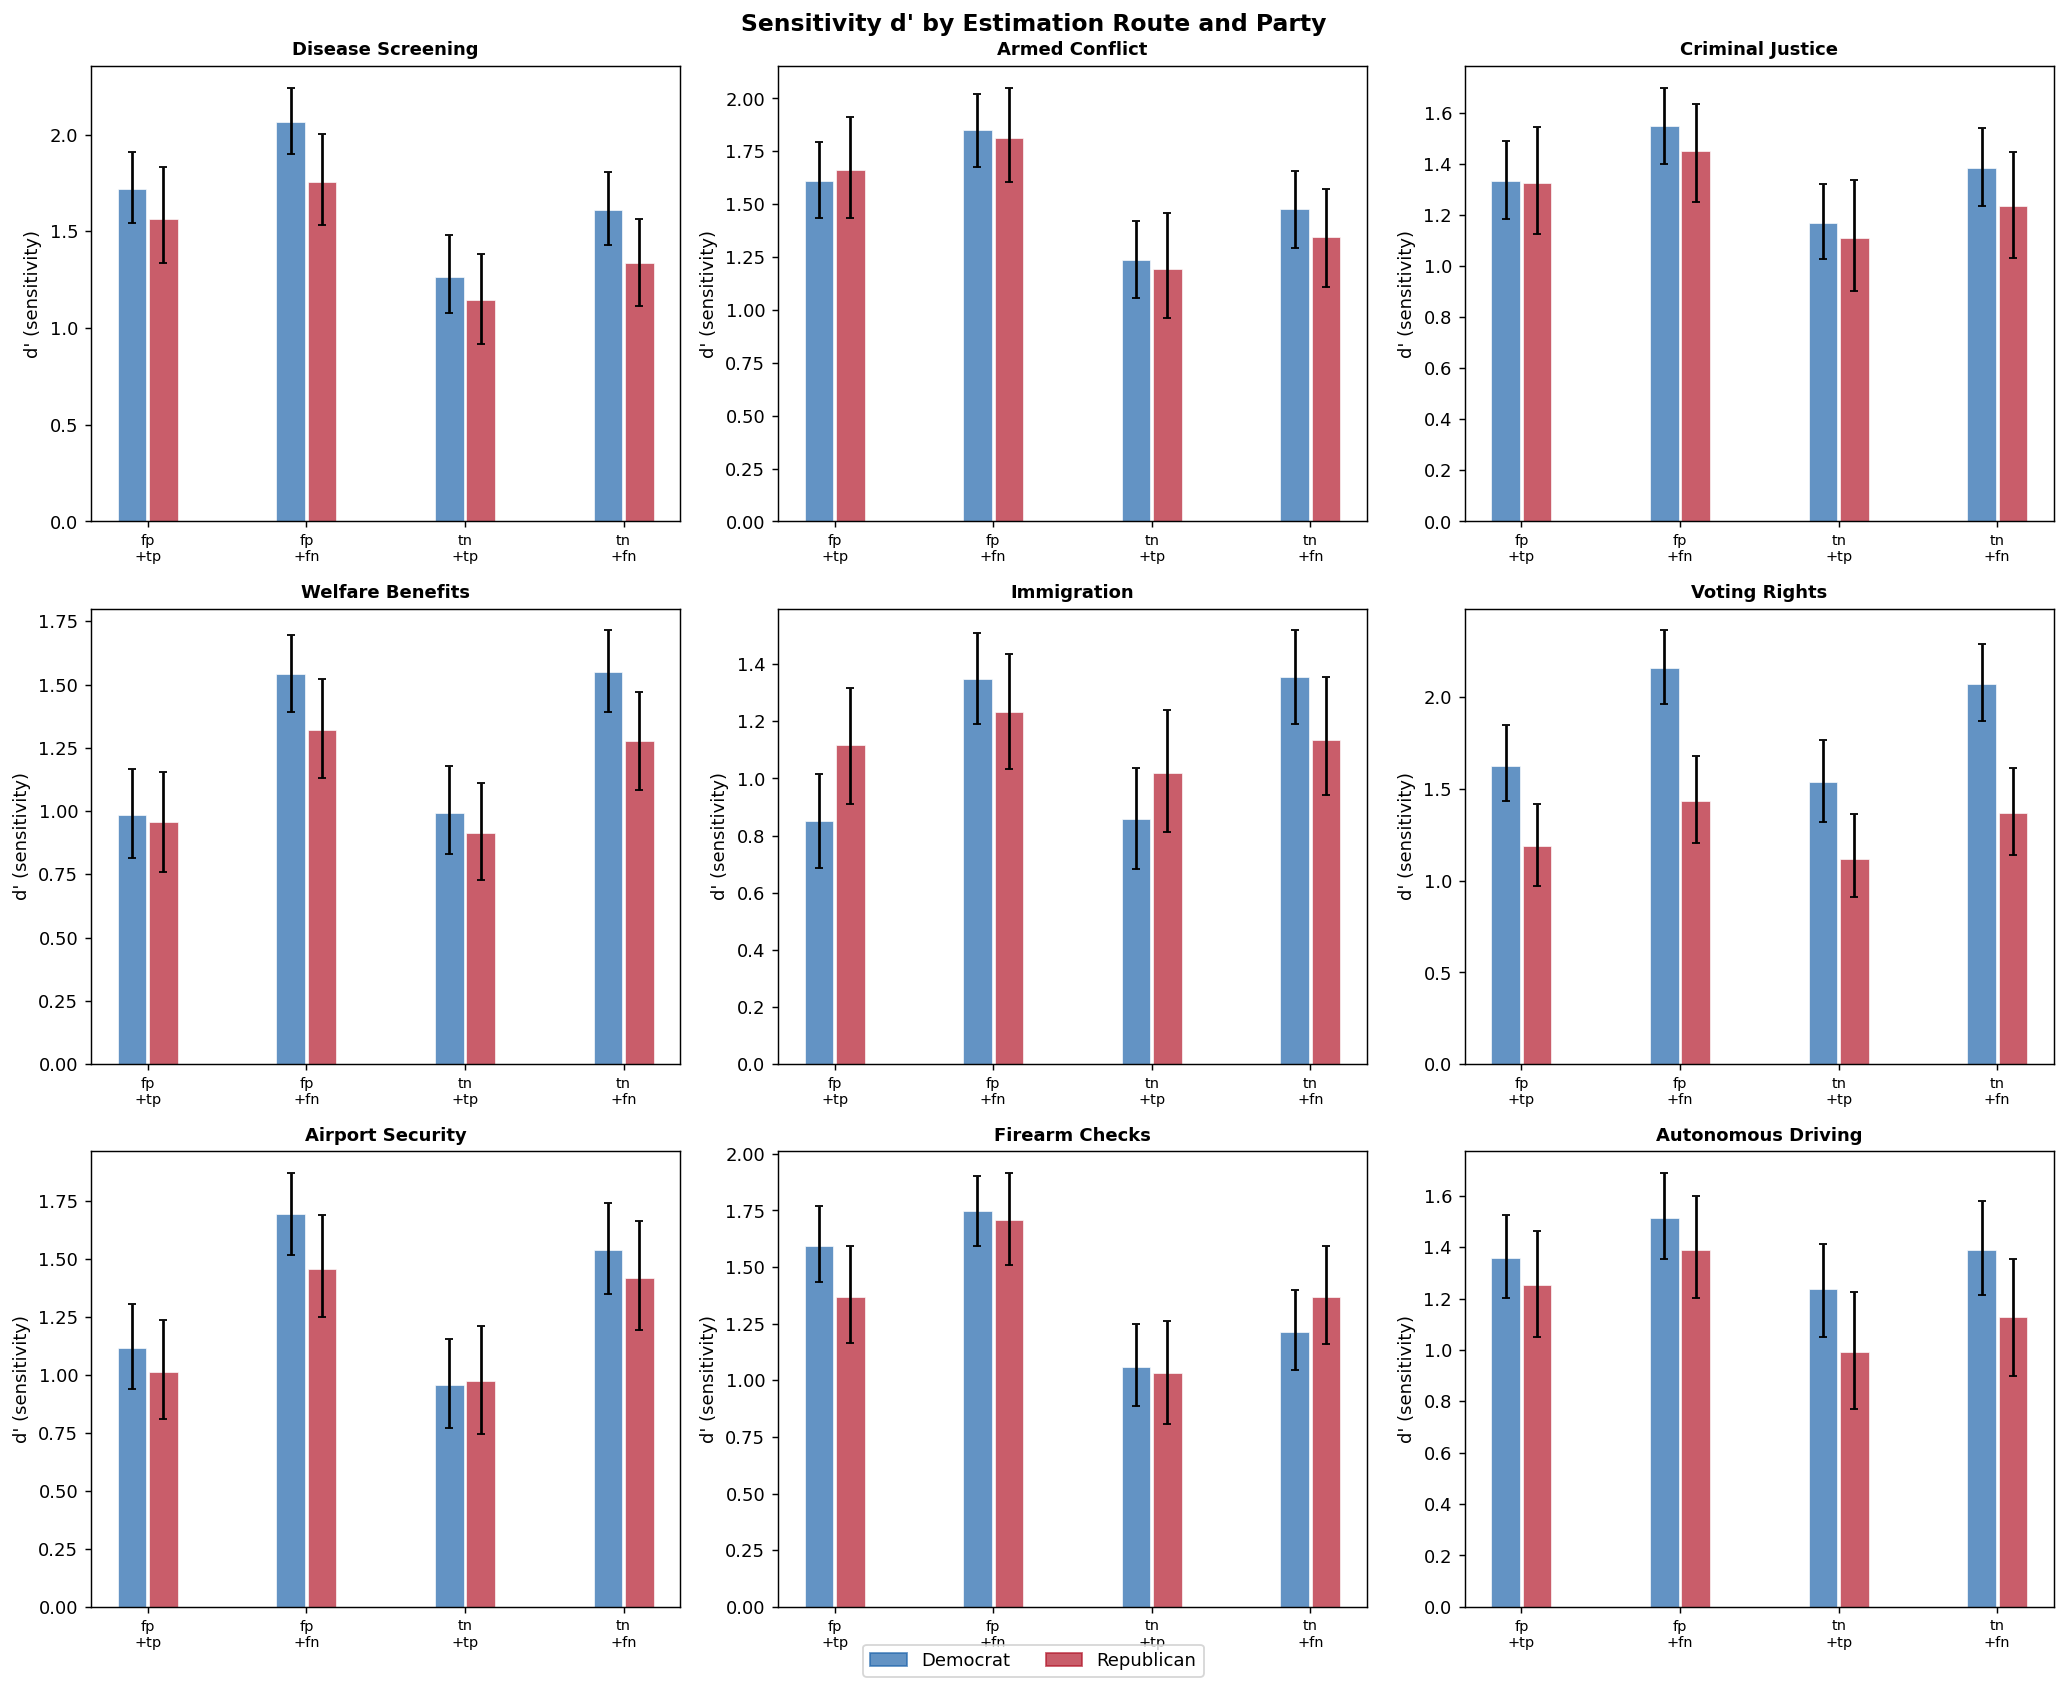

In [16]:
# --- Plot: d' by party and route, across themes ---

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for idx, theme in enumerate(THEMES):
    ax = axes[idx]
    t_data = rt_ci[rt_ci['theme'] == theme]

    for r_idx, route in enumerate(routes_ordered):
        for p_idx, party in enumerate(['Democrat', 'Republican']):
            row = t_data[(t_data['route'] == route) & (t_data['party'] == party)]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            x = r_idx + (p_idx - 0.5) * bar_width * 1.1

            yerr_lo = row['d_prime'] - row['d_lo']
            yerr_hi = row['d_hi'] - row['d_prime']
            ax.bar(x, row['d_prime'], bar_width, color=PARTY_COLORS[party], alpha=0.7,
                   yerr=[[yerr_lo], [yerr_hi]], capsize=2, edgecolor='white', linewidth=0.5)

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xticks(range(len(routes_ordered)))
    ax.set_xticklabels([r.replace('+', '\n+') for r in routes_ordered], fontsize=8)
    ax.set_title(THEME_LABELS[theme], fontweight='bold', fontsize=10)
    ax.set_ylabel("d' (sensitivity)")

fig.legend(handles=[dem_patch, rep_patch], loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Sensitivity d' by Estimation Route and Party",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dprime_by_route_party_theme.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Cross-Theme Heatmap: Route Discrepancy Δc

For each party × theme, compute max - min of c across routes.  
This measures **how much the estimation route matters** for that cell.

In [17]:
# Also compute specific route contrasts:
# Δc_direct_vs_complement = c(fp+tp) - c(tn+fn)
# This is the cleanest test of framing bias

contrast_rows = []
for party in ['Democrat', 'Republican']:
    for theme in THEMES:
        sub = rt[(rt['party'] == party) & (rt['theme'] == theme)]

        direct = sub[sub['route'] == 'fp+tp']
        complement = sub[sub['route'] == 'tn+fn']

        row = {'party': party, 'theme': theme, 'theme_label': THEME_LABELS[theme]}

        # c range across all routes
        if len(sub) >= 2:
            row['c_range'] = sub['c'].max() - sub['c'].min()
            row['c_mean'] = sub['c'].mean()
            row['d_range'] = sub['d_prime'].max() - sub['d_prime'].min()
            row['d_mean'] = sub['d_prime'].mean()

        # Direct vs complement contrast
        if len(direct) > 0 and len(complement) > 0:
            row['delta_c_direct_vs_comp'] = direct['c'].values[0] - complement['c'].values[0]
            row['delta_d_direct_vs_comp'] = direct['d_prime'].values[0] - complement['d_prime'].values[0]
            row['fpr_direct'] = direct['fpr'].values[0]
            row['fpr_complement'] = complement['fpr'].values[0]
            row['tpr_direct'] = direct['tpr'].values[0]
            row['tpr_complement'] = complement['tpr'].values[0]

        contrast_rows.append(row)

contrasts = pd.DataFrame(contrast_rows)

# Print table
print('='*90)
print('Δc (direct errors vs complement of correct): fp+tp route minus tn+fn route')
print('Positive = asking about errors directly → more conservative c')
print('='*90)
for party in ['Democrat', 'Republican']:
    print(f'\n  {party}')
    sub = contrasts[contrasts['party'] == party]
    for _, row in sub.iterrows():
        dc = row.get('delta_c_direct_vs_comp', np.nan)
        if not np.isnan(dc):
            print(f'    {row["theme_label"]:<22} Δc={dc:+.3f}  '
                  f'(FPR: {row["fpr_direct"]:.3f} vs {row["fpr_complement"]:.3f}, '
                  f'TPR: {row["tpr_direct"]:.3f} vs {row["tpr_complement"]:.3f})')

Δc (direct errors vs complement of correct): fp+tp route minus tn+fn route
Positive = asking about errors directly → more conservative c

  Democrat
    Disease Screening      Δc=+0.399  (FPR: 0.135 vs 0.258, TPR: 0.731 vs 0.832)
    Armed Conflict         Δc=+0.306  (FPR: 0.160 vs 0.267, TPR: 0.731 vs 0.804)
    Criminal Justice       Δc=+0.188  (FPR: 0.247 vs 0.301, TPR: 0.742 vs 0.805)
    Welfare Benefits       Δc=+0.274  (FPR: 0.270 vs 0.267, TPR: 0.645 vs 0.823)
    Immigration            Δc=+0.245  (FPR: 0.334 vs 0.331, TPR: 0.664 vs 0.821)
    Voting Rights          Δc=+0.311  (FPR: 0.164 vs 0.187, TPR: 0.742 vs 0.882)
    Airport Security       Δc=+0.369  (FPR: 0.237 vs 0.288, TPR: 0.655 vs 0.836)
    Firearm Checks         Δc=+0.343  (FPR: 0.123 vs 0.265, TPR: 0.667 vs 0.720)
    Autonomous Driving     Δc=+0.138  (FPR: 0.224 vs 0.262, TPR: 0.726 vs 0.775)

  Republican
    Disease Screening      Δc=+0.305  (FPR: 0.181 vs 0.312, TPR: 0.744 vs 0.801)
    Armed Conflict         

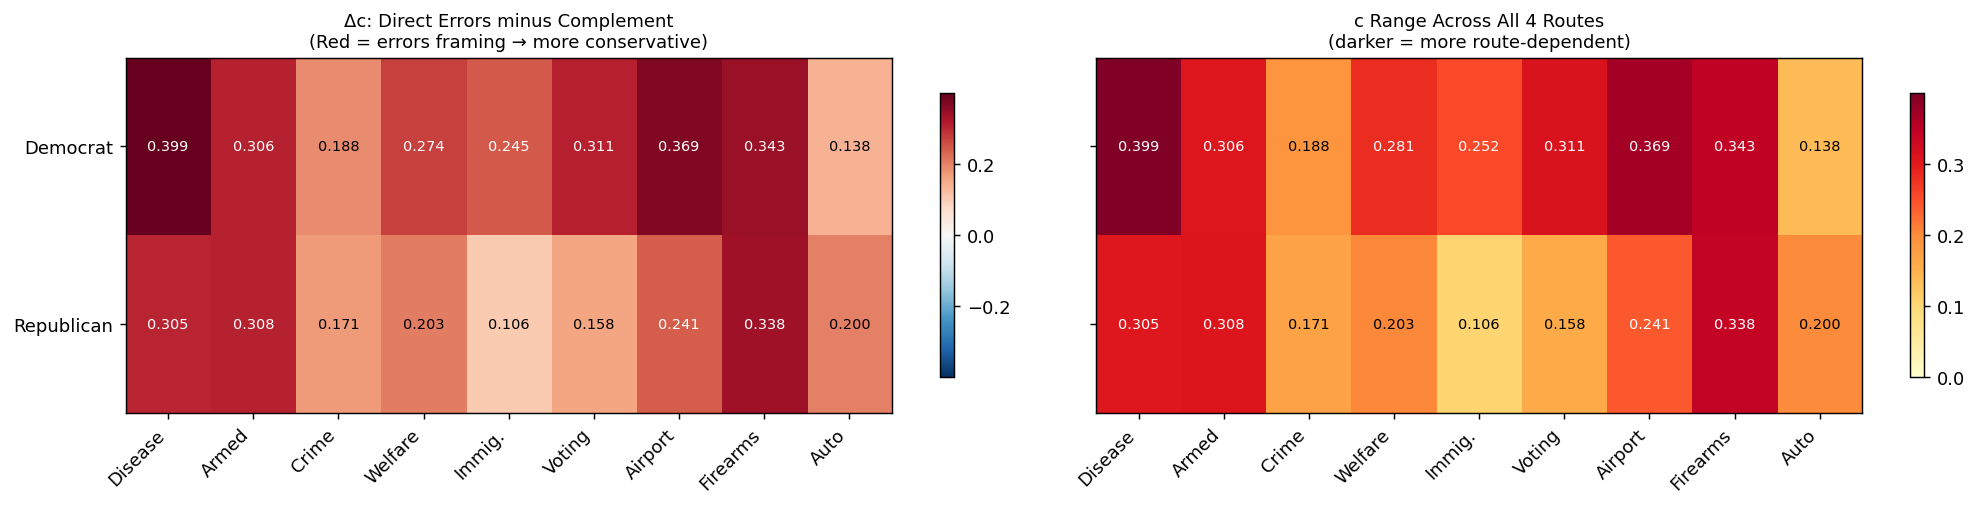

In [18]:
# Heatmap: Δc (direct vs complement) by party × theme

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax_idx, metric in enumerate(['delta_c_direct_vs_comp', 'c_range']):
    ax = axes[ax_idx]
    parties = ['Democrat', 'Republican']
    matrix = np.full((len(parties), len(THEMES)), np.nan)

    for i, party in enumerate(parties):
        for j, theme in enumerate(THEMES):
            row = contrasts[(contrasts['party']==party) & (contrasts['theme']==theme)]
            if len(row) > 0 and metric in row.columns:
                val = row[metric].values[0]
                if not np.isnan(val):
                    matrix[i, j] = val

    if metric == 'delta_c_direct_vs_comp':
        vmax = np.nanmax(np.abs(matrix)) if not np.all(np.isnan(matrix)) else 1
        im = ax.imshow(matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_title('Δc: Direct Errors minus Complement\n(Red = errors framing → more conservative)', fontsize=10)
    else:
        im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, aspect='auto')
        ax.set_title('c Range Across All 4 Routes\n(darker = more route-dependent)', fontsize=10)

    ax.set_xticks(range(len(THEMES)))
    ax.set_xticklabels([THEME_SHORT[t] for t in THEMES], rotation=45, ha='right')
    ax.set_yticks(range(len(parties)))
    ax.set_yticklabels(parties)

    for i in range(len(parties)):
        for j in range(len(THEMES)):
            val = matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8,
                       color='white' if abs(val) > 0.6 * np.nanmax(np.abs(matrix)) else 'black')

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('route_discrepancy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. ROC AUC Comparison

For each party × theme, compute the AUC implied by each route's d'.  
Under equal-variance Gaussian SDT: $\mathrm{AUC} = \Phi(d'/\sqrt{2})$

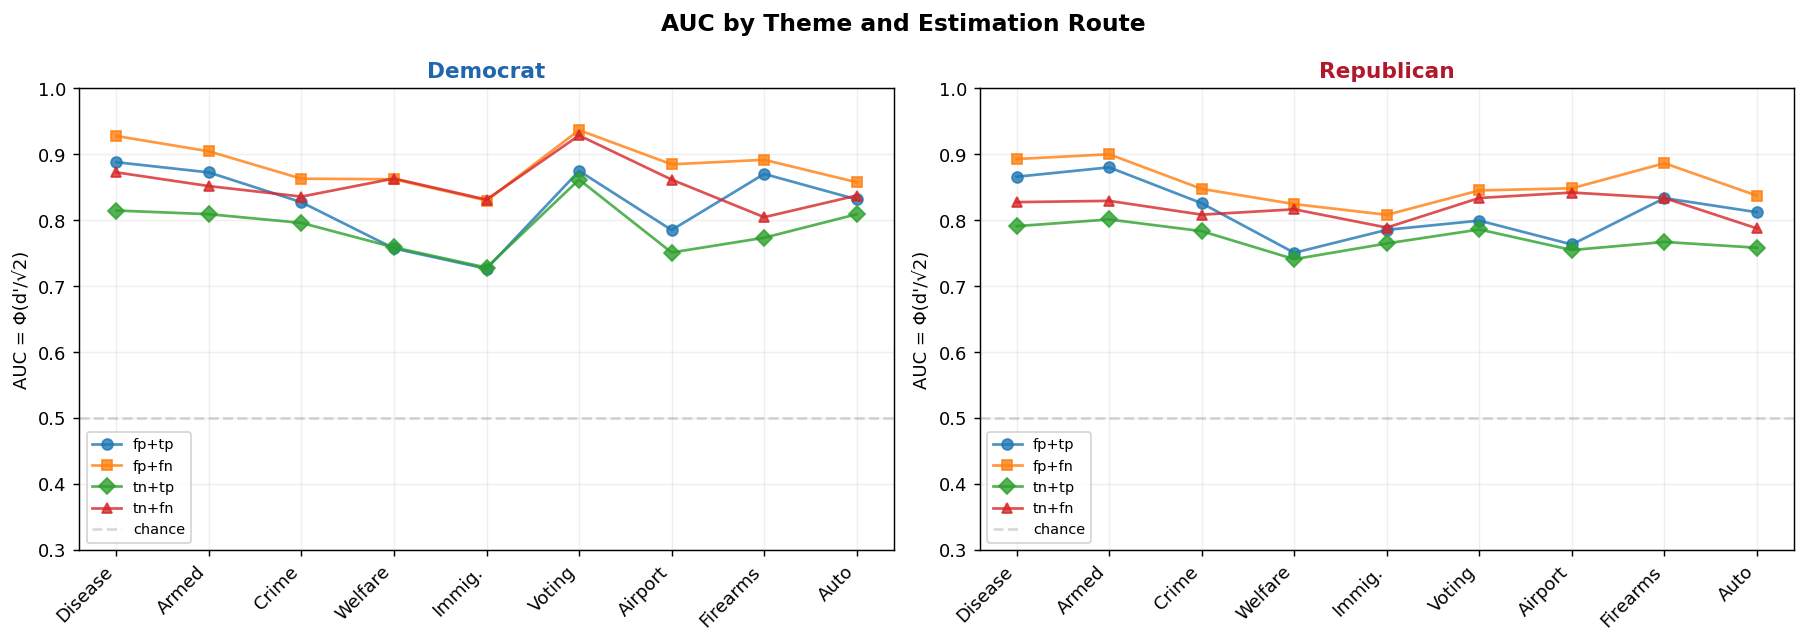

In [19]:
# Compute AUC from d'
rt['auc'] = stats.norm.cdf(rt['d_prime'] / np.sqrt(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, party in enumerate(['Democrat', 'Republican']):
    ax = axes[ax_idx]
    sub = rt[rt['party'] == party]

    for route in routes_ordered:
        r_data = sub[sub['route'] == route]
        if len(r_data) == 0:
            continue
        x = np.arange(len(THEMES))
        aucs = []
        for theme in THEMES:
            row = r_data[r_data['theme'] == theme]
            aucs.append(row['auc'].values[0] if len(row) > 0 else np.nan)

        ax.plot(x, aucs, marker=ROUTE_MARKERS[route], label=route, alpha=0.8, markersize=6)

    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3, label='chance')
    ax.set_xticks(range(len(THEMES)))
    ax.set_xticklabels([THEME_SHORT[t] for t in THEMES], rotation=45, ha='right')
    ax.set_ylabel('AUC = Φ(d\'/√2)')
    ax.set_title(f'{party}', fontweight='bold', color=PARTY_COLORS[party])
    ax.legend(fontsize=8)
    ax.set_ylim(0.3, 1.0)
    ax.grid(True, alpha=0.2)

fig.suptitle('AUC by Theme and Estimation Route', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('auc_by_route_party.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Consistency Pairs Diagnostic (FP+TN, FN+TP)

For participants who got same-population pairs, check whether  
the sum → 1000 constraint holds, and whether deviations are partisan.

In [20]:
consist_rows = []
for theme in THEMES:
    for pair_type, (col_a, col_b) in [('FP+TN', ('fp', 'tn')), ('FN+TP', ('fn', 'tp'))]:
        col_a_name = base_col(theme, col_a)
        col_b_name = base_col(theme, col_b)

        if col_a_name not in df.columns or col_b_name not in df.columns:
            continue

        both = df[[col_a_name, col_b_name, PARTY_COL]].dropna(subset=[col_a_name, col_b_name])
        both[col_a_name] = pd.to_numeric(both[col_a_name], errors='coerce')
        both[col_b_name] = pd.to_numeric(both[col_b_name], errors='coerce')
        both = both.dropna()

        if len(both) == 0:
            continue

        both['sum'] = both[col_a_name] + both[col_b_name]
        both['deviation'] = both['sum'] - 1000

        for party_label in ['Democrat', 'Republican', 'Overall']:
            if party_label == 'Overall':
                sub = both
            else:
                sub = both[both[PARTY_COL].isin(PARTY_GROUPS[party_label])]

            if len(sub) < 2:
                continue

            consist_rows.append({
                'theme': theme, 'pair': pair_type, 'party': party_label,
                'n': len(sub),
                'mean_sum': sub['sum'].mean(),
                'mean_deviation': sub['deviation'].mean(),
                'mean_abs_deviation': sub['deviation'].abs().mean(),
                'pct_perfect': (sub['sum'] == 1000).mean() * 100,
                'pct_close': ((sub['sum'] >= 950) & (sub['sum'] <= 1050)).mean() * 100,
            })

consist_df = pd.DataFrame(consist_rows)

if len(consist_df) > 0:
    print('='*80)
    print('WITHIN-POPULATION CONSISTENCY: Do complementary questions sum to 1000?')
    print('='*80)
    print(f'\n{"Theme":<15} {"Pair":<8} {"Party":<12} {"n":>4} {"Mean Sum":>10} '
          f'{"Mean Dev":>10} {"% Perfect":>10} {"% ±50":>8}')
    print('-'*80)
    for _, row in consist_df.sort_values(['theme', 'pair', 'party']).iterrows():
        print(f'{THEME_SHORT[row["theme"]]:<15} {row["pair"]:<8} {row["party"]:<12} '
              f'{row["n"]:>4.0f} {row["mean_sum"]:>10.1f} {row["mean_deviation"]:>+10.1f} '
              f'{row["pct_perfect"]:>9.1f}% {row["pct_close"]:>7.1f}%')

    # Key diagnostic: is mean deviation significantly ≠ 0? And is it partisan?
    print('\n\nKey finding: Mean deviation from 1000 tells us if groups are ')
    print('systematically OVER-counting (>1000) or UNDER-counting (<1000) total outcomes.')
    print('Partisan differences in deviation direction = different framing biases by party.')
else:
    print('No consistency pairs found in the data (likely due to randomization giving SDT pairs instead).')

WITHIN-POPULATION CONSISTENCY: Do complementary questions sum to 1000?

Theme           Pair     Party           n   Mean Sum   Mean Dev  % Perfect    % ±50
--------------------------------------------------------------------------------
Airport         FN+TP    Democrat      119      829.3     -170.7      34.5%    55.5%
Airport         FN+TP    Overall       232      831.7     -168.3      30.2%    53.9%
Airport         FN+TP    Republican     89      847.1     -152.9      20.2%    49.4%
Airport         FP+TN    Democrat      106      944.7      -55.3      24.5%    50.0%
Airport         FP+TN    Overall       205      969.7      -30.3      27.8%    50.2%
Airport         FP+TN    Republican     68     1004.0       +4.0      27.9%    48.5%
Armed           FN+TP    Democrat      107      943.6      -56.4      20.6%    47.7%
Armed           FN+TP    Overall       206      946.4      -53.6      22.3%    50.0%
Armed           FN+TP    Republican     74      961.8      -38.2      23.0%    48.

---
## 10. Summary: What the Multi-Route Analysis Tells Us

Key diagnostics from this analysis:

1. **If routes agree** → The SDT estimates are robust to question framing.  
   Asking about errors vs. correct outcomes doesn't change perceived rates.

2. **If direct-error routes (fp+tp, fp+fn) yield higher FPR/lower TPR** →  
   People **overestimate errors** when asked about them directly.  
   "How many false positives?" elicits higher numbers than  
   "How many true negatives?" → (1000 - TN) would imply.

3. **If the framing bias is partisan** →  
   One party's SDT parameters are more sensitive to question framing.  
   This connects directly to H6 (valence framing hypothesis) and  
   the brainstorming insight about which form of reporting is "more divisive."

4. **If the framing bias is theme-specific** →  
   Politically charged themes might show larger framing effects,  
   supporting the idea that political identity amplifies error salience.

5. **Distance from Bayesian optimal c** →  
   Shows how far each party's criterion is from a rational baseline  
   given the base rate. Useful for characterizing partisan bias as  
   deviations from optimality rather than just differences from each other.